平均方法与提升方法对比
1 平均方法中，各个基础模型是独立的，彼此之间没有关系。
提升方法中，各个基础模型是相关的，后面模型会在前面模型的预测基础之上，进行改进。
2 平均方法各个基础模型可以并行训练，但是提升方法只能串行训练。
3 平均方法能够有效降低模型的方差，因此适合集成具有高方差的模型（强模型）。
提升方法能够有效降低模型的偏差，因此适合集成具有高偏差的模型（弱模型）。

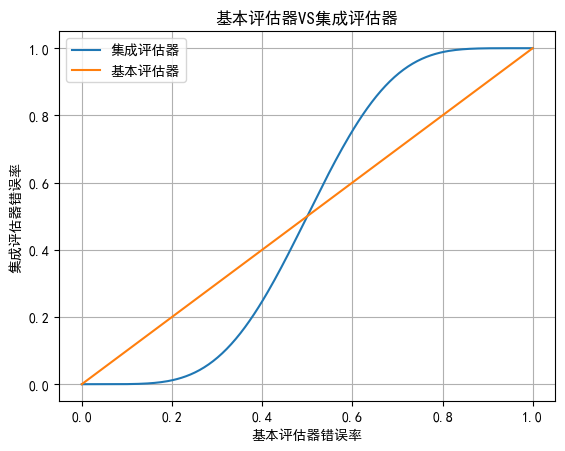

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb# 组合数计算函数
def ensemble_error(n,error):
    #计算集成评估器的出错率
    #Parameters:
    #n:int,基本评估器数量
    #error:array-like,shape=(num,1),基本评估器的错误率
    #Return:
    #result:ndarray,shape=(num,),每个基本评估器错误率下对应的集成评估器错误率
    error=np.asarray(error)
    #集成出错,至少要半数基本评估器出错
    start=np.ceil(n/2)
    #集成出错,基本评估器错误的数量区间
    k=np.arange(start,n+1)
    v=comb(n,k)*error**k*(1-error)**(n-k)
    return np.sum(v,axis=1)
ensemble_error(11,[[0.25],[0.3]])#以0.5为分水岭

#定义基本评估器出错概率区间
error=np.linspace(0,1,200)
ens_error=ensemble_error(11,error[:,np.newaxis])
plt.plot(error,ens_error,label='集成评估器')
plt.plot(error,error,label='基本评估器')
plt.xlabel('基本评估器错误率')
plt.ylabel('集成评估器错误率')
plt.title('基本评估器VS集成评估器')
plt.legend()
plt.grid()

In [ ]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
X,y=make_classification(n_samples=1000,n_features=20,n_informative=15,
n_classes=3,random_state=0,flip_y=0.2)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,
random_state=0)
tree=DecisionTreeClassifier()
tree.fit(X_train,y_train)
print('决策树正确率')
print(tree.score(X_train,y_train))
print(tree.score(X_test,y_test))

#estimator:要集成的基本评估器
#n_estimators:集成基本评估器的数量
#max_samples:抽取子集最大样本数量(比例)
#max_features:抽取最大特征的数量(比例)
#bootstrap:样本是否放回抽样
#bootstrap_features:特征是否放回抽样
bag=BaggingClassifier(estimator=tree,n_estimators=100,
max_samples=0.8,max_features=0.8,bootstrap=True,bootstrap_features=True)
bag.fit(X_train,y_train)
print("Bagging正确率:")
print(bag.score(X_train,y_train))
print(bag.score(X_test,y_test))

决策正确率
1.0
0.5
Bagging正确率:
1.0
0.64


In [4]:
#回归示例
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
X,y=make_regression(n_samples=1000,n_features=10,n_informative=1,
noise=5,random_state=0,bias=2)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,
random_state=0)
lr=LinearRegression()
lr.fit(X_train,y_train)
print('线性回归R^2值')
print(lr.score(X_train,y_train))
print(lr.score(X_test,y_test))
bag=BaggingRegressor(estimator=lr,n_estimators=100,
max_samples=0.9,max_features=0.9,bootstrap=True)
bag.fit(X_train,y_train)
print('Bagging R^2值')
print(bag.score(X_train,y_train))
print(bag.score(X_test,y_test))

线性回归R^2值
0.7840875886798451
0.7815429442986225
Bagging R^2值
0.7761064533069856
0.7717495747982761


In [5]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_classes=2,
                          random_state=0, flip_y=0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
print("决策树正确率：")
print(tree.score(X_train, y_train))
print(tree.score(X_test, y_test))

rf = RandomForestClassifier(n_estimators=100, criterion="gini", random_state=0, bootstrap=True,
                           max_samples=0.9, max_features="sqrt")
rf.fit(X_train, y_train)
print("随机森林正确率：")
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

et = ExtraTreesClassifier(n_estimators=100, criterion="gini", random_state=0, bootstrap=True,
                           max_samples=0.9, max_features="sqrt")
et.fit(X_train, y_train)
print("极度随机树正确率：")
print(et.score(X_train, y_train))
print(et.score(X_test, y_test))

决策树正确率：
1.0
0.7966666666666666
随机森林正确率：
1.0
0.8533333333333334
极度随机树正确率：
1.0
0.87


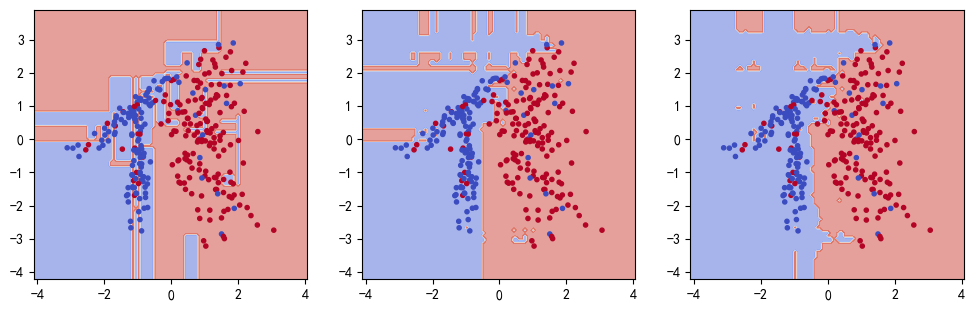

In [6]:
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(12,3.5))
for index,model in enumerate([tree,rf,et],start=1):
    ax=plt.subplot(1,3,index)
    model.fit(X_train,y_train)
    DecisionBoundaryDisplay.from_estimator(model,X_test,response_method='predict',
    alpha=0.5,ax=ax,cmap=plt.cm.coolwarm)
    ax.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap=plt.cm.coolwarm,marker='.')

(1797, 64) (1797,)
[0 1 2 3 4 5 6 7 8 9]
[178 182 177 183 181 182 181 179 174 180]
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


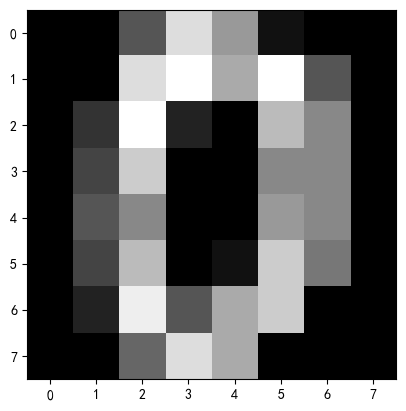

In [7]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
print(X.shape, y.shape)
print(np.unique(y))
print(np.bincount(y))
print(X[0].reshape(8, 8))
plt.imshow(X[0].reshape(8, 8), cmap="gray")

(359, 64) (359,)


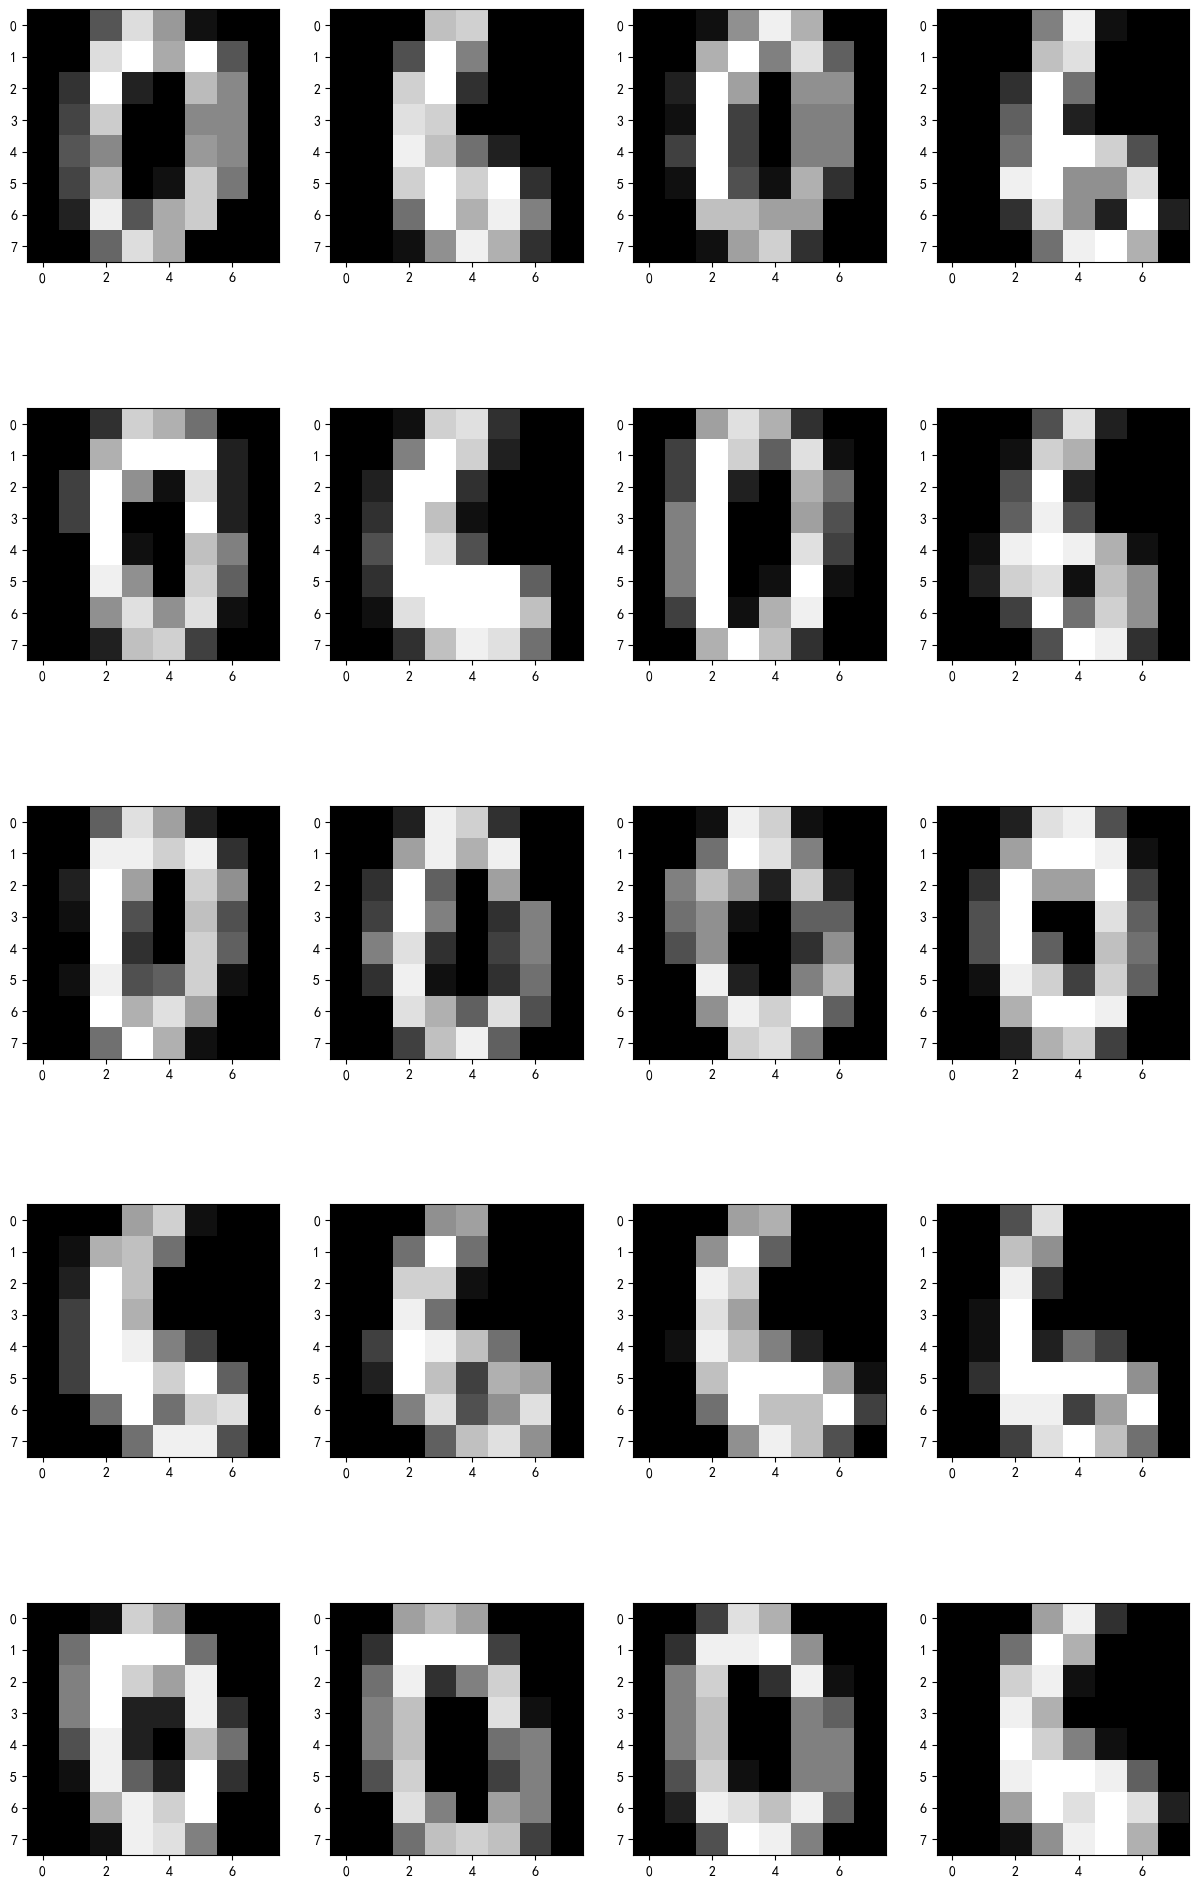

In [8]:



mask = (y == 0) | (y  == 6)
X = X[mask]
y = y[mask]
print(X.shape, y.shape)
row, col = 5, 4
fig, ax = plt.subplots(row, col, figsize=(15, row * 5))
ax = ax.ravel()
for i in range(row * col):
    ax[i].imshow(X[i].reshape(8, 8), cmap="gray")




In [9]:
rf = RandomForestClassifier(n_estimators=100, max_features=0.8, random_state=0, bootstrap=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))




1.0
0.9777777777777777


[0.00000000e+00 0.00000000e+00 0.00000000e+00 2.95987522e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.05814323e-03 0.00000000e+00
 0.00000000e+00 1.17059220e-03 1.77105507e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 6.30078012e-01 2.48360434e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.50582176e-04
 1.47466240e-03 3.75576746e-03 1.13109998e-01 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.10600731e-02
 2.11829553e-01 4.38229704e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 6.04712911e-03
 1.02643771e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.42595224e-04
 0.00000000e+00 3.23552847e-03 5.72049061e-04 0.00000000e+00]


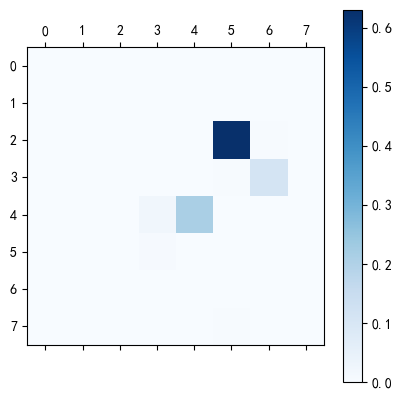

In [10]:
importance = rf.feature_importances_
print(importance)
importance = importance.reshape(8, 8)
plt.matshow(importance, cmap=plt.cm.Blues)
plt.colorbar()

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

X, y = make_classification(n_samples=5000, n_features=10, n_informative=3,
                          n_classes=3, random_state=0, flip_y=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
knn = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression()
tree = DecisionTreeClassifier()

# estimators：指定要集成的基础模型。该参数为一个包含元组的列表，每个元组含有两个元素，
#            (模型名称, 模型对象)，该参数格式与流水线类似。
e = [("knn", knn), ("lr", lr), ("tree", tree)]
vote = VotingClassifier(estimators=e)
for name, model in e + [("voting", vote)]:
    print(name)
    model.fit(X_train, y_train)
    print(model.score(X_test, y_test))



knn
0.596
lr
0.62
tree
0.5616
voting
0.6464


In [12]:
from sklearn.model_selection import GridSearchCV

params = {
    "knn__n_neighbors": [5, 8, 11],
    "knn__weights": ["uniform", "distance"],
    "lr__C": [0.01, 0.1, 1, 10],
    "tree__max_depth": [5, 7, 9, None],
    "voting": ["hard", "soft"],
    "weights": [[1, 1, 1], [1, 1.2, 1]]
}

grid = GridSearchCV(estimator=vote, param_grid=params, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)
print(grid.score(X_test, y_test))

{'knn__n_neighbors': 11, 'knn__weights': 'uniform', 'lr__C': 0.01, 'tree__max_depth': 5, 'voting': 'soft', 'weights': [1, 1, 1]}
0.6584
0.6656


In [14]:
from sklearn.ensemble import VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_friedman1

# 生成非线性数据集。
X, y = make_friedman1(n_samples=5000, n_features=10, noise=2, random_state=2323)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=223)
knn = KNeighborsRegressor(n_neighbors=5)
lr = LinearRegression()
tree = DecisionTreeRegressor()
e = [("knn", knn), ("lr", lr), ("tree", tree)]
vote = VotingRegressor(estimators=e)
for name, model in e + [("voting", vote)]:
    print(name)
    model.fit(X_train, y_train)
    print(model.score(X_test, y_test))



knn
0.6663605902294054
lr
0.6466846206650265
tree
0.5268846148857973
voting
0.7218529229109513


In [15]:
params = {
    "knn__n_neighbors": [5, 8, 11],
    "knn__weights": ["uniform", "distance"],
    "tree__max_depth": [5, 7, 9, None],
    "weights": [[1, 1, 1], [1, 1, 0.8]]
}

grid = GridSearchCV(estimator=vote, param_grid=params, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)
print(grid.score(X_test, y_test))

{'knn__n_neighbors': 5, 'knn__weights': 'distance', 'tree__max_depth': 9, 'weights': [1, 1, 1]}
0.7453000542237855
0.7305898157774724


In [16]:
from sklearn.ensemble import StackingClassifier

X, y = make_classification(n_samples=5000, n_features=10, n_informative=3, n_classes=3, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=223)
knn = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression()
tree = DecisionTreeClassifier()
rf = RandomForestClassifier(n_estimators=200)
e = [("knn", knn), ("lr", lr), ("tree", tree)]
# estimators：设置基础模型。
# final_estimator：设置最终模型（元模型）。
# stack_method：在分类任务中，设置基础模型的预测结果，用来训练最终模型。
# passthrough：训练最终模型是否使用训练基础模型的特征，默认为False。
stack = StackingClassifier(estimators=e, final_estimator=rf, cv=5, n_jobs=-1)
for name, model in e + [("rf", rf), ("stack", stack)]:
    print(name)
    model.fit(X_train, y_train)
    print(model.score(X_test, y_test))

knn
0.774
lr
0.7406666666666667
tree
0.8073333333333333
rf
0.864
stack
0.8186666666666667
